In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 95.4 MB/s eta 0:00:00


Using data file: /kaggle/input/multi-class-12class-ssd-hdd/RANSAP_win7-120gb-ssd_12CLASS.npy

EXPERIMENT 1: BINARY CLASSIFICATION (Benign vs Ransomware)

LOADING RANSAP DATA
Loaded data shape: (303481, 6)
Features shape: (303481, 5)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Label distribution:
  Class 0: 10690 samples (3.5%)
  Class 1: 35137 samples (11.6%)
  Class 2: 37637 samples (12.4%)
  Class 3: 11358 samples (3.7%)
  Class 4: 11080 samples (3.7%)
  Class 5: 37635 samples (12.4%)
  Class 6: 35466 samples (11.7%)
  Class 7: 11307 samples (3.7%)
  Class 8: 35593 samples (11.7%)
  Class 9: 33795 samples (11.1%)
  Class 10: 33694 samples (11.1%)
  Class 11: 10089 samples (3.3%)

Converting to binary classification...
Binary distribution: Benign=10690, Ransomware=292791
Balanced to 10690 samples per class
Subsampled to 1500 samples

Final dataset:
  Training: 1200 samples
  Testing: 300 samples

1. QSVM with ZZ Feature Map
----------------------------------------

Training R

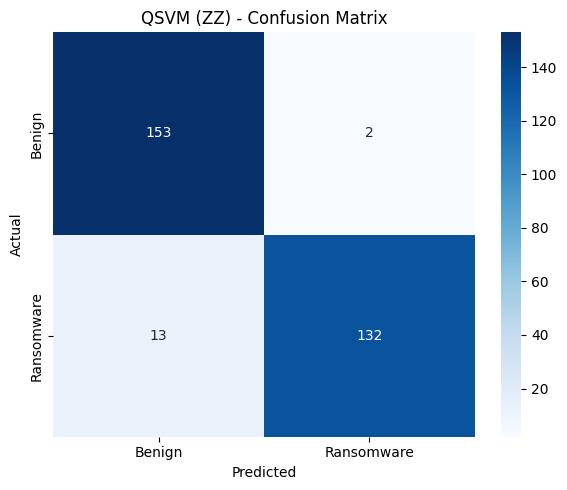


2. QSVM with RanSAP Feature Map
----------------------------------------

Training RanSAP QSVM...
  Feature map: RanSAP
  Circuit reps: 2
  Entanglement: linear
  Classes: 2
Training binary classifier...
Computing kernel matrix (1200x1200)...
  Progress: 0.0% (100/720600)
  Progress: 0.0% (200/720600)
  Progress: 0.0% (300/720600)
  Progress: 0.1% (400/720600)
  Progress: 0.1% (500/720600)
  Progress: 0.1% (600/720600)
  Progress: 0.1% (700/720600)
  Progress: 0.1% (800/720600)
  Progress: 0.1% (900/720600)
  Progress: 0.1% (1000/720600)
  Progress: 0.2% (1100/720600)
  Progress: 0.2% (1200/720600)
  Progress: 0.2% (1300/720600)
  Progress: 0.2% (1400/720600)
  Progress: 0.2% (1500/720600)
  Progress: 0.2% (1600/720600)
  Progress: 0.2% (1700/720600)
  Progress: 0.2% (1800/720600)
  Progress: 0.3% (1900/720600)
  Progress: 0.3% (2000/720600)
  Progress: 0.3% (2100/720600)
  Progress: 0.3% (2200/720600)
  Progress: 0.3% (2300/720600)
  Progress: 0.3% (2400/720600)
  Progress: 0.3% (250

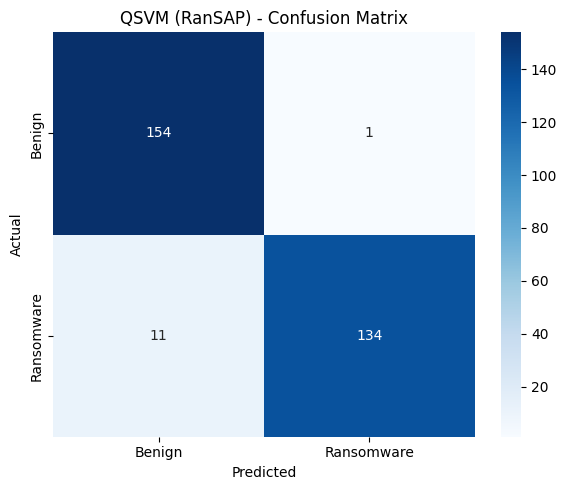


3. Classical SVM (Baseline)
----------------------------------------
Classical SVM Accuracy: 0.9833

EXPERIMENT 2: MULTI-CLASS (26 Ransomware Families)

LOADING RANSAP DATA
Loaded data shape: (303481, 6)
Features shape: (303481, 5)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Label distribution:
  Class 0: 10690 samples (3.5%)
  Class 1: 35137 samples (11.6%)
  Class 2: 37637 samples (12.4%)
  Class 3: 11358 samples (3.7%)
  Class 4: 11080 samples (3.7%)
  Class 5: 37635 samples (12.4%)
  Class 6: 35466 samples (11.7%)
  Class 7: 11307 samples (3.7%)
  Class 8: 35593 samples (11.7%)
  Class 9: 33795 samples (11.1%)
  Class 10: 33694 samples (11.1%)
  Class 11: 10089 samples (3.3%)
Subsampled to 840 samples

Final dataset:
  Training: 672 samples
  Testing: 168 samples

Multi-Class QSVM with ZZ Feature Map
----------------------------------------

Training RanSAP QSVM...
  Feature map: ZZ
  Circuit reps: 1
  Entanglement: linear
  Classes: 12
Training multi-class classifier (ov

ValueError: Number of classes, 12, does not match size of target_names, 26. Try specifying the labels parameter

In [2]:
import numpy as np
import pennylane as qml
import torch
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# =====================================================
# QSVM Implementation for RanSAP Multi-Class Data
# =====================================================

class RanSAPQuantumSVM:
    """
    Quantum SVM specifically designed for RanSAP ransomware classification.
    Handles the 5-feature format and multi-class (26 classes) classification.
    """
    
    def __init__(self, n_qubits=5, feature_map='ZZ', reps=2, 
                 entanglement='linear', multiclass_strategy='ovr'):
        """
        Initialize QSVM for RanSAP data.
        
        Args:
            n_qubits: Number of qubits (should be 5 for RanSAP features)
            feature_map: Type of quantum feature map
            reps: Number of circuit repetitions
            entanglement: Entanglement pattern
            multiclass_strategy: 'ovr' (One-vs-Rest) or 'ovo' (One-vs-One)
        """
        self.n_qubits = n_qubits
        self.feature_map = feature_map
        self.reps = reps
        self.entanglement = entanglement
        self.multiclass_strategy = multiclass_strategy
        
        # Quantum device
        self.dev = qml.device("lightning.qubit", wires=n_qubits)
        
        # Will store the classifiers
        self.classifier = None
        self.X_train_scaled = None
        self.scaler = None
        self.feature_normalizer = None
        
    def preprocess_ransap_features(self, X):
        """
        Preprocess RanSAP features for quantum circuits.
        The 5 features have very different scales, so careful normalization is needed.
        """
        # Feature names for reference
        feature_names = [
            'Feature_1 (Time-based)',      # ~500k range
            'Feature_2 (Time-based)',      # ~270k range
            'Feature_3 (Large metric)',    # ~10^14 range
            'Feature_4 (Large metric)',    # ~10^14 range
            'Feature_5 (Probability)'      # 0-1 range
        ]
        
        # Apply log transformation to large features (3rd and 4th columns)
        X_transformed = X.copy()
        X_transformed[:, 2] = np.log1p(X[:, 2])  # log(1+x) for feature 3
        X_transformed[:, 3] = np.log1p(X[:, 3])  # log(1+x) for feature 4
        
        return X_transformed
    
    def _apply_feature_map(self, x, wires):
        """Apply quantum feature map to encode RanSAP data."""
    
        if self.feature_map == 'ZZ':
            # ZZ Feature Map - good for data with correlations
            for rep in range(self.reps):
                # Hadamard layer
                for wire in wires:
                    qml.Hadamard(wires=wire)
            
                # Phase encoding
                for i, wire in enumerate(wires):
                    qml.RZ(2.0 * x[i], wires=wire)
            
                # Entanglement with data-dependent gates
                if self.entanglement == 'full':
                    for i in range(len(wires)):
                        for j in range(i + 1, len(wires)):
                            qml.CZ(wires=[wires[i], wires[j]])
                        
                            # MODIFIED SECTION: Decomposed RZZ gate
                            phi = (x[i] * x[j]) * np.pi
                            qml.CNOT(wires=[wires[i], wires[j]])
                            qml.RZ(phi, wires=wires[j])
                            qml.CNOT(wires=[wires[i], wires[j]])
                            
                elif self.entanglement == 'linear':
                    for i in range(len(wires) - 1):
                        qml.CZ(wires=[wires[i], wires[i + 1]])
                    
                        # MODIFIED SECTION: Decomposed RZZ gate
                        phi = (x[i] * x[i + 1]) * np.pi
                        qml.CNOT(wires=[wires[i], wires[i + 1]])
                        qml.RZ(phi, wires=wires[i + 1])
                        qml.CNOT(wires=[wires[i], wires[i + 1]])
                        
        elif self.feature_map == 'RanSAP':
        # Custom feature map for RanSAP data characteristics
        # Designed for mixed-scale features
        
        # Initial encoding based on feature importance
        # Features 3 & 4 (large metrics) get special treatment
            qml.RY(x[0] * np.pi, wires=0)  # Time feature 1
            qml.RY(x[1] * np.pi, wires=1)  # Time feature 2
            qml.RX(x[2] * np.pi, wires=2)  # Large metric 1 (log-scaled)
            qml.RX(x[3] * np.pi, wires=3)  # Large metric 2 (log-scaled)
            qml.RZ(x[4] * 2 * np.pi, wires=4)  # Probability feature
        
            for rep in range(self.reps):
            # Entangle correlated features
                qml.CNOT(wires=[0, 1])  # Time features likely correlated
                qml.CNOT(wires=[2, 3])  # Large metrics likely correlated
                qml.CNOT(wires=[4, 0])  # Probability affects time
            
            # Additional rotations
                for i in range(5):
                    qml.RY(x[i] * (rep + 1) * 0.5, wires=i)
            
            # Full entanglement in last repetition
                if rep == self.reps - 1:
                    for i in range(4):
                        qml.CNOT(wires=[i, i + 1])
                        
        elif self.feature_map == 'Pauli':
        # Standard Pauli feature map
            for rep in range(self.reps):
                for i, wire in enumerate(wires):
                    qml.RY(x[i] * np.pi, wires=wire)
                    qml.RZ(x[i] * np.pi, wires=wire)
            
            # Entanglement
                if rep < self.reps - 1:
                    for i in range(len(wires) - 1):
                        qml.CNOT(wires=[wires[i], wires[i + 1]])
    
    def compute_kernel(self, x1, x2):
        """Compute quantum kernel between two RanSAP data points."""
        @qml.qnode(self.dev)
        def kernel_circuit():
            self._apply_feature_map(x1, range(self.n_qubits))
            qml.adjoint(self._apply_feature_map)(x2, range(self.n_qubits))
            return qml.probs(wires=range(self.n_qubits))
        
        # Return fidelity (probability of |00000⟩ state for 5 qubits)
        return kernel_circuit()[0]
    
    def compute_kernel_matrix(self, X1, X2=None, verbose=True):
        """Compute kernel matrix with progress tracking."""
        if X2 is None:
            X2 = X1
            symmetric = True
        else:
            symmetric = False
        
        n1, n2 = len(X1), len(X2)
        K = np.zeros((n1, n2))
        
        total_computations = n1 * n2 if not symmetric else n1 * (n1 + 1) // 2
        computed = 0
        
        if verbose:
            print(f"Computing kernel matrix ({n1}x{n2})...")
        
        for i in range(n1):
            for j in range(i if symmetric else 0, n2):
                K[i, j] = self.compute_kernel(X1[i], X2[j])
                if symmetric and i != j:
                    K[j, i] = K[i, j]
                
                computed += 1
                if verbose and computed % 100 == 0:
                    progress = (computed / total_computations) * 100
                    print(f"  Progress: {progress:.1f}% ({computed}/{total_computations})")
        
        return K
    
    def fit(self, X, y, C=1.0):
        """
        Train QSVM on RanSAP data.
        
        Args:
            X: Training features (5 RanSAP features)
            y: Training labels (0-25 for 26 ransomware families)
            C: SVM regularization parameter
        """
        print(f"\nTraining RanSAP QSVM...")
        print(f"  Feature map: {self.feature_map}")
        print(f"  Circuit reps: {self.reps}")
        print(f"  Entanglement: {self.entanglement}")
        print(f"  Classes: {len(np.unique(y))}")
        
        # Preprocess features
        X_preprocessed = self.preprocess_ransap_features(X)
        
        # Scale features to [-1, 1] range for quantum circuits
        self.scaler = MinMaxScaler(feature_range=(-1, 1))
        self.X_train_scaled = self.scaler.fit_transform(X_preprocessed)
        
        # For binary classification (benign vs ransomware)
        if len(np.unique(y)) == 2:
            print("Training binary classifier...")
            
            # Compute kernel matrix
            K_train = self.compute_kernel_matrix(self.X_train_scaled)
            
            # Train SVM
            self.classifier = SVC(kernel='precomputed', C=C, probability=True)
            self.classifier.fit(K_train, y)
            
        # For multi-class classification (12 ransomware families)
        else:
            print(f"Training multi-class classifier ({self.multiclass_strategy})...")
            
            if self.multiclass_strategy == 'ovr':
                # One-vs-Rest strategy
                self.classifier = []
                
                for class_label in np.unique(y):
                    print(f"\nTraining classifier for class {class_label}...")
                    
                    # Create binary labels
                    y_binary = (y == class_label).astype(int)
                    
                    # Compute kernel matrix
                    K_train = self.compute_kernel_matrix(self.X_train_scaled, verbose=False)
                    
                    # Train binary SVM
                    svm = SVC(kernel='precomputed', C=C, probability=True)
                    svm.fit(K_train, y_binary)
                    
                    self.classifier.append({
                        'label': class_label,
                        'svm': svm
                    })
            else:
                # One-vs-One strategy (would create 66 classifiers for 12 classes)
                print("OvO strategy not implemented in this version")
                return None
        
        print("\nTraining complete!")
        return self
    
    def predict(self, X):
        """Make predictions on new RanSAP data."""
        # Preprocess and scale
        X_preprocessed = self.preprocess_ransap_features(X)
        X_scaled = self.scaler.transform(X_preprocessed)
        
        # Binary classification
        if not isinstance(self.classifier, list):
            print("Making binary predictions...")
            K_test = self.compute_kernel_matrix(X_scaled, self.X_train_scaled, verbose=False)
            return self.classifier.predict(K_test)
        
        # Multi-class classification (OvR)
        else:
            print("Making multi-class predictions...")
            n_samples = len(X_scaled)
            n_classes = len(self.classifier)
            
            # Get probability scores from each classifier
            scores = np.zeros((n_samples, n_classes))
            
            for i, clf_dict in enumerate(self.classifier):
                K_test = self.compute_kernel_matrix(X_scaled, self.X_train_scaled, verbose=False)
                proba = clf_dict['svm'].predict_proba(K_test)
                scores[:, i] = proba[:, 1]  # Probability of being this class
            
            # Return class with highest score
            return np.argmax(scores, axis=1)
    
    def score(self, X, y):
        """Calculate accuracy score."""
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)


# =====================================================
# Data Loading and Preprocessing
# =====================================================

def load_ransap_data(file_path, binary=True, test_size=0.2, subsample=None):
    """
    Load and prepare RanSAP data.
    
    Args:
        file_path: Path to .npy file
        binary: If True, convert to binary (benign vs ransomware)
        test_size: Fraction for test set
        subsample: Number of samples to use (None for all)
    """
    print("\n" + "="*50)
    print("LOADING RANSAP DATA")
    print("="*50)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # Load data
    data = np.load(file_path)
    print(f"Loaded data shape: {data.shape}")
    
    # RanSAP format: 5 features + 1 label
    X = data[:, :5]  # First 5 columns are features
    y = data[:, 5].astype(int)  # Last column is label (0-11)
    
    print(f"Features shape: {X.shape}")
    print(f"Unique labels: {np.unique(y)}")
    print(f"Label distribution:")
    for label in np.unique(y):
        count = np.sum(y == label)
        print(f"  Class {label}: {count} samples ({count/len(y)*100:.1f}%)")
    
    # Convert to binary if requested
    if binary:
        print("\nConverting to binary classification...")
        y = np.where(y == 0, 0, 1)  # 0=benign, 1=ransomware
        print(f"Binary distribution: Benign={np.sum(y==0)}, Ransomware={np.sum(y==1)}")
        
        # Balance classes
        benign_idx = np.where(y == 0)[0]
        ransomware_idx = np.where(y == 1)[0]
        min_samples = min(len(benign_idx), len(ransomware_idx))
        
        balanced_idx = np.concatenate([
            np.random.choice(benign_idx, min_samples, replace=False),
            np.random.choice(ransomware_idx, min_samples, replace=False)
        ])
        np.random.shuffle(balanced_idx)
        
        X = X[balanced_idx]
        y = y[balanced_idx]
        print(f"Balanced to {min_samples} samples per class")
    
    # Subsample if requested
    if subsample and subsample < len(X):
        if binary:
            # Stratified sampling for binary
            idx = np.random.choice(len(X), subsample, replace=False)
        else:
            # Ensure we have samples from each class
            samples_per_class = max(1, subsample // len(np.unique(y)))
            idx = []
            for label in np.unique(y):
                class_idx = np.where(y == label)[0]
                n_samples = min(samples_per_class, len(class_idx))
                idx.extend(np.random.choice(class_idx, n_samples, replace=False))
            idx = np.array(idx[:subsample])
            np.random.shuffle(idx)
        
        X = X[idx]
        y = y[idx]
        print(f"Subsampled to {len(X)} samples")
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    print(f"\nFinal dataset:")
    print(f"  Training: {len(X_train)} samples")
    print(f"  Testing: {len(X_test)} samples")
    
    return X_train, X_test, y_train, y_test


def evaluate_ransap_qsvm(model, X_test, y_test, model_name="QSVM", binary=True):
    """Evaluate QSVM on RanSAP test data."""
    print(f"\nEvaluating {model_name}...")
    
    # Make predictions
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    print("\n" + "="*50)
    print(f"{model_name} RESULTS")
    print("="*50)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Prediction time: {pred_time:.2f} seconds")
    
    # Classification report
    if binary:
        target_names = ['Benign', 'Ransomware']
    else:
        target_names = [f'Class_{i}' for i in range(26)]
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8 if not binary else 6, 7 if not binary else 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    return accuracy, pred_time


# =====================================================
# Main Execution
# =====================================================

if __name__ == "__main__":
    # File paths (try multiple possible locations)
    possible_paths = [
        "/kaggle/input/multi-class-12class-ssd-hdd/RANSAP_win7-120gb-ssd_12CLASS.npy"
    ]
    
    npy_file = None
    for path in possible_paths:
        if os.path.exists(path):
            npy_file = path
            break
    
    if npy_file is None:
        print("ERROR: No RanSAP data file found!")
        exit(1)
    
    print(f"Using data file: {npy_file}")
    
    # =========================================
    # EXPERIMENT 1: Binary Classification
    # =========================================
    print("\n" + "="*60)
    print("EXPERIMENT 1: BINARY CLASSIFICATION (Benign vs Ransomware)")
    print("="*60)
    
    # Load data for binary classification
    X_train, X_test, y_train, y_test = load_ransap_data(
        npy_file,
        binary=True,
        test_size=0.2,
        subsample=1500  # Use 500 for quick test, None for full
    )
    
    # Train QSVM with different feature maps
    results_binary = {}
    
    # 1. QSVM with ZZ Feature Map
    print("\n1. QSVM with ZZ Feature Map")
    print("-" * 40)
    qsvm_zz = RanSAPQuantumSVM(
        n_qubits=5,
        feature_map='ZZ',
        reps=2,
        entanglement='linear'
    )
    
    start = time.time()
    qsvm_zz.fit(X_train, y_train, C=1.0)
    train_time = time.time() - start
    
    acc, pred_time = evaluate_ransap_qsvm(qsvm_zz, X_test, y_test, "QSVM (ZZ)", binary=True)
    results_binary['QSVM (ZZ)'] = {'accuracy': acc, 'train_time': train_time}
    
    # 2. QSVM with Custom RanSAP Feature Map
    print("\n2. QSVM with RanSAP Feature Map")
    print("-" * 40)
    qsvm_ransap = RanSAPQuantumSVM(
        n_qubits=5,
        feature_map='RanSAP',
        reps=2,
        entanglement='linear'
    )
    
    start = time.time()
    qsvm_ransap.fit(X_train, y_train, C=1.0)
    train_time = time.time() - start
    
    acc, pred_time = evaluate_ransap_qsvm(qsvm_ransap, X_test, y_test, "QSVM (RanSAP)", binary=True)
    results_binary['QSVM (RanSAP)'] = {'accuracy': acc, 'train_time': train_time}
    
    # 3. Classical SVM for comparison
    print("\n3. Classical SVM (Baseline)")
    print("-" * 40)
    
    # Preprocess for classical SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    classical_svm = SVC(kernel='rbf', C=1.0)
    start = time.time()
    classical_svm.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    
    y_pred = classical_svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Classical SVM Accuracy: {acc:.4f}")
    results_binary['Classical SVM'] = {'accuracy': acc, 'train_time': train_time}
    
    # =========================================
    # EXPERIMENT 2: Multi-Class Classification
    # =========================================
    print("\n" + "="*60)
    print("EXPERIMENT 2: MULTI-CLASS (26 Ransomware Families)")
    print("="*60)
    
    # Load data for multi-class
    X_train_mc, X_test_mc, y_train_mc, y_test_mc = load_ransap_data(
        npy_file,
        binary=False,
        test_size=0.2,
        subsample=850  # Smaller sample for multi-class due to complexity
    )
    
    # Train multi-class QSVM
    print("\nMulti-Class QSVM with ZZ Feature Map")
    print("-" * 40)
    qsvm_multiclass = RanSAPQuantumSVM(
        n_qubits=5,
        feature_map='ZZ',
        reps=1,  # Fewer reps for speed in multi-class
        entanglement='linear',
        multiclass_strategy='ovr'
    )
    
    start = time.time()
    qsvm_multiclass.fit(X_train_mc, y_train_mc, C=1.0)
    train_time = time.time() - start
    
    acc_mc, pred_time_mc = evaluate_ransap_qsvm(
        qsvm_multiclass, X_test_mc, y_test_mc, 
        "Multi-Class QSVM", binary=False
    )
    
    # =========================================
    # FINAL SUMMARY
    # =========================================
    print("\n" + "="*60)
    print("FINAL RESULTS SUMMARY")
    print("="*60)
    
    print("\nBinary Classification Results:")
    print(f"{'Model':<20} {'Accuracy':<10} {'Train Time (s)':<15}")
    print("-" * 45)
    for model, metrics in results_binary.items():
        print(f"{model:<20} {metrics['accuracy']:<10.4f} {metrics['train_time']:<15.2f}")
    
    print(f"\nMulti-Class Classification:")
    print(f"  QSVM (26 classes): {acc_mc:.4f} accuracy, {train_time:.2f}s training")